# Rule Extraction — Holdout (Train/Test Split)

Rule extraction on a stratified train/test split. **Prerequisite:** run
`pipe.run_baseline_split(k_values=...)` (notebook 02, section 2b) first for
every k you want rule extraction on — this notebook no longer derives its
own split/FS; it reuses `outputs_baseline_split/k{k}/{dataset}/` directly.

For each k in `holdout.rare_class_k_values` (a subset of the split-baseline's
own k sweep), for each dataset, this notebook:

1. Reads the split (train/test row indices) and feature-selection artifacts
   (`holdout.fs_methods` — boruta, mrmr_k50, mrmr_k75) already written by
   `run_baseline_split()`.
2. Trains each rule model (`holdout.models` — rf, decisiontree)
   `holdout.n_repeats` times, keeps the best run by `holdout.select_metric`,
   and records **both train- and test-set metrics** of the winner.
3. Mines rules from the winning model, evaluates them on train + a
   generalisation check on test, runs SHAP.
4. Cross-checks rf vs. decisiontree rules; writes a provenance comparison.
5. Exports the held-out test set for later single-sample UI testing.


## Setup

In [1]:
import sys
import json
import warnings
from pathlib import Path

# Make src.* importable from the notebooks/ directory
REPO_ROOT = Path("..").resolve()
sys.path.insert(0, str(REPO_ROOT))

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning, module="sklearn")

import numpy as np
import pandas as pd
from IPython.display import Image, display

from src.pipeline import GeneExpressionPipeline

pipe = GeneExpressionPipeline(
    config_root=str(REPO_ROOT / "configs"),
    output_root=str(REPO_ROOT / "outputs_baseline_full"),  # unused by this flow; kept for pipe.print_summary()
    use_wandb=False,
)

# outputs_holdout/k{K}/ -- where this notebook's results land, one per k.
HOLDOUT_ROOT = REPO_ROOT / "outputs_holdout"
SPLIT_ROOT = REPO_ROOT / "outputs_baseline_split"


## Run Holdout Rule Extraction

`pipe.run_rule_extraction_holdout(dataset_names=None, k_values=K_VALUES)` —
all enabled datasets, sweeping every k in `K_VALUES`. Each k must already have
`outputs_baseline_split/k{k}/{dataset}/` populated (run notebook 02's section
2b first) — this cell will report and skip any (dataset, k, fs_method) combo
that's missing artifacts rather than fail the whole run.


╭─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╮
│ Rule Extraction (Holdout) — Train/Test Split                                                                    │
│ Stratified split · train-only FS · repeated training · best-by-metric                                           │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

──────────────────────────────────────────── Dataset: GEO-Breast-20711 ────────────────────────────────────────────

  → Loading GEO-Breast-20711 (min_samples_per_class=4)

    Split: 74 train / 14 test · 4 classes survive (< 4 dropped)

  Provenance log appended -> C:\Users\Bao Nguyen\LearningWithClaude\LV_code\outputs_holdout\GEO-Breast-20711\DATASET_PROVENANCE_HOLDOUT.md


...

  SHAP explainer: tree (model=DecisionTreeClassifier)
  Probe->gene collapse: 50 probes -> 45 genes (0 unmapped)
  Provenance -> C:\Users\Bao Nguyen\LearningWithClaude\LV_code\outputs_holdout\CuMiDa-Brain-50161\mrmr_miq\dt\rules\shap\text\probe_to_gene_metadata.csv
  SHAP plots saved -> C:\Users\Bao Nguyen\LearningWithClaude\LV_code\outputs_holdout\CuMiDa-Brain-50161\mrmr_miq\dt\rules\shap\plots
  SHAP matrix -> C:\Users\Bao Nguyen\LearningWithClaude\LV_code\outputs_holdout\CuMiDa-Brain-50161\mrmr_miq\dt\rules\shap\text\shap_feature_importance_matrix.csv
  Gene lists -> C:\Users\Bao Nguyen\LearningWithClaude\LV_code\outputs_holdout\CuMiDa-Brain-50161\mrmr_miq\dt\rules\shap\text\top_shap_genes_by_class.txt


  ✓ SHAP complete → C:\Users\Bao 
Nguyen\LearningWithClaude\LV_code\outputs_holdout\CuMiDa-Brain-50161\mrmr_miq\dt\rules\shap

  ✓ Cross-check rf vs decisiontree: 1 identical rule(s), 16 shared gene-direction literal(s) (literal Jaccard=0.12)
-> C:\Users\Bao Nguyen\LearningWithClaude\LV_code\outputs_holdout\CuMiDa-Brain-50161\mrmr_miq\compare

  ✓ Holdout comparison → DATASET_PROVENANCE_HOLDOUT.md

{'GEO-Breast-20711': {'boruta': {'models': {'rf': {'n_rules': 80,
     'coverage': 1.0,
     'mean_fidelity': 0.9679,
     'per_class': {'Basal': 20, 'HER2': 20, 'LumA': 20, 'LumB': 20},
     'n_rules_raw': 1764,
     'n_rules_passed_filter': 867,
     'n_rules_kept': 80,
     'n_dropped_by_filter': 897,
     'n_dropped_by_cap': 787,
     'best_seed': 0,
     'best_run_test_metrics': {'accuracy': 0.8571428571428571,
      'balanced_accuracy': 0.875,
      'f1': 0.8517857142857144,
      'f1_macro': 0.8517857142857144,
      'precision': 0.8541666666666666,
      'recall': 0.875,
      'roc_auc': 0.8958333333333334,
      'log_loss': 0.7233129795099177}},
    'decisiontree': {'n_rules': 6,
     'coverage': 0.9054,
     'mean_fidelity': 1.0,
     'per_class': {'Basal': 2, 'HER2': 2, 'LumA': 1, 'LumB': 1},
     'n_rules_raw': 9,
     'n_rules_passed_filter': 6,
     'n_rules_kept': 6,
     'n_dropped_by_filter': 3,
     'n_dropped_by_cap': 0,
     'best_seed': 4,
     'best_run_test_metri

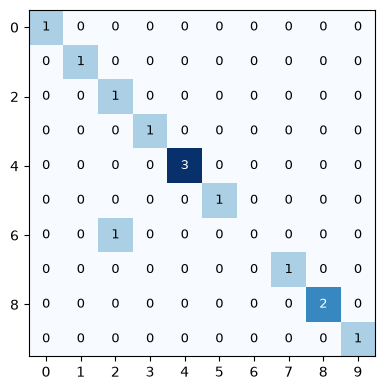

In [2]:
holdout_cfg = dict(pipe.config_loader.load_yaml('holdout.yaml').get('holdout', {}))
K_VALUES = holdout_cfg.get('batch', {}).get('rare_class_k_values', [3, 4, 5])
print(f"Rule extraction for k={K_VALUES}")

all_k_results = pipe.run_rule_extraction_holdout(dataset_names=None, k_values=K_VALUES)
all_k_results


## Inspect the Split

Choose which k to inspect below (`INSPECT_K`, defaults to the first of `K_VALUES`).
Rare-class removal (< that k) and the stratified train/test partition are read from
the split-baseline's artifacts (`outputs_baseline_split/k{k}/{dataset}/`) that this
run reused — not re-derived here.


In [3]:
INSPECT_K = K_VALUES[0]
DATASET = 'GEO-Breast-20711'
ds_root = HOLDOUT_ROOT / f'k{INSPECT_K}' / DATASET
split_root_ds = SPLIT_ROOT / f'k{INSPECT_K}' / DATASET

split_info = json.loads((split_root_ds / 'split_info.json').read_text())
print(json.dumps(split_info, indent=2))


{
  "dataset": "GEO-Breast-20711",
  "min_samples_per_class": 4,
  "test_size": 0.15,
  "split_random_state": 42,
  "n_samples_total": 88,
  "n_train": 74,
  "n_test": 14,
  "class_labels": [
    "Basal",
    "HER2",
    "LumA",
    "LumB"
  ],
  "train_class_counts": {
    "Basal": 23,
    "HER2": 22,
    "LumA": 11,
    "LumB": 18
  },
  "test_class_counts": {
    "Basal": 4,
    "HER2": 4,
    "LumA": 2,
    "LumB": 4
  }
}


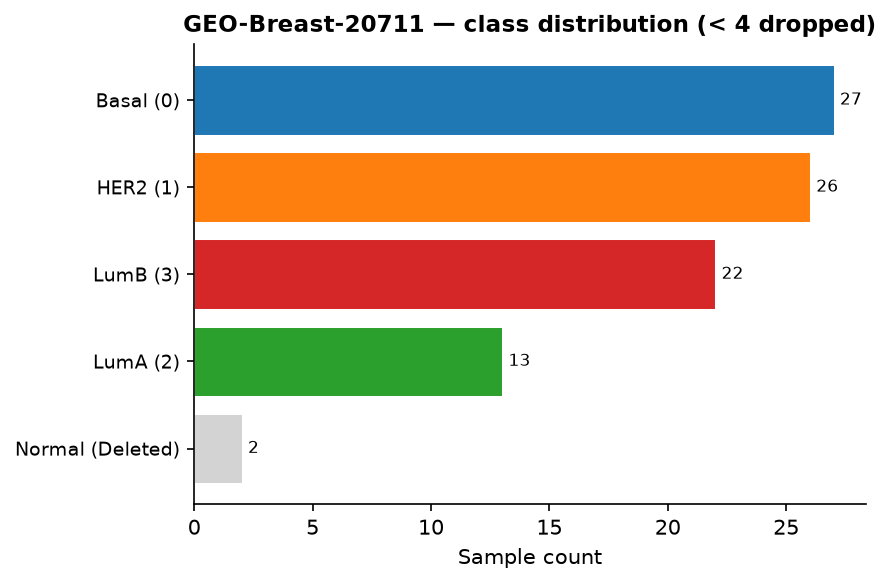

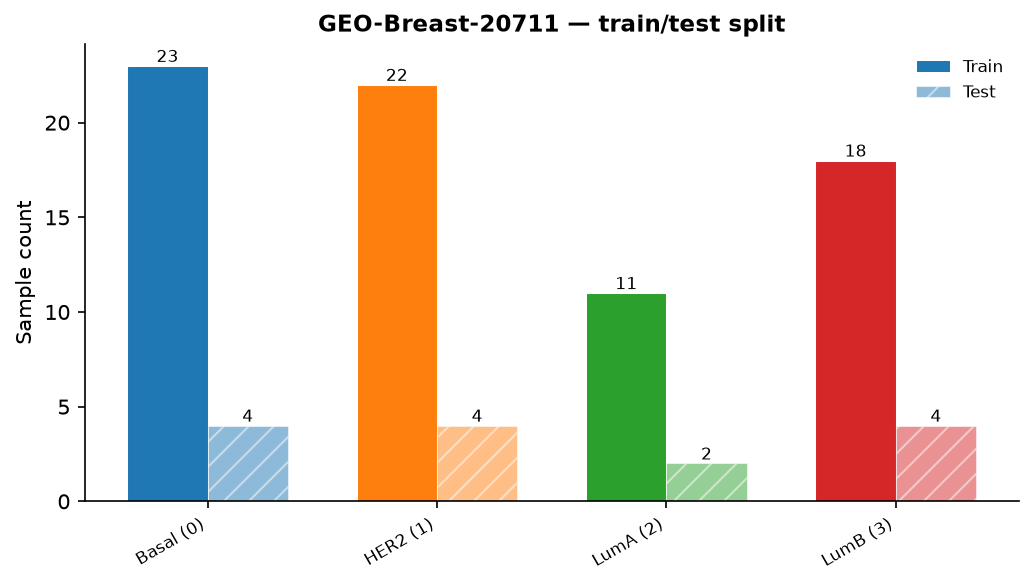

In [4]:
display(Image(filename=str(split_root_ds / 'visualizations' / 'class_distribution_after_dropna.png')))
display(Image(filename=str(split_root_ds / 'visualizations' / 'train_test_split.png')))


### All datasets — class distribution overview

`run_baseline_split()` already generates this combined grid automatically per k
(`outputs_baseline_split/k{k}/visualizations/`) — just display it, no need to
rebuild it here.


Saved -> C:\Users\Bao Nguyen\LearningWithClaude\LV_code\outputs_holdout\_all_class_distributions.png


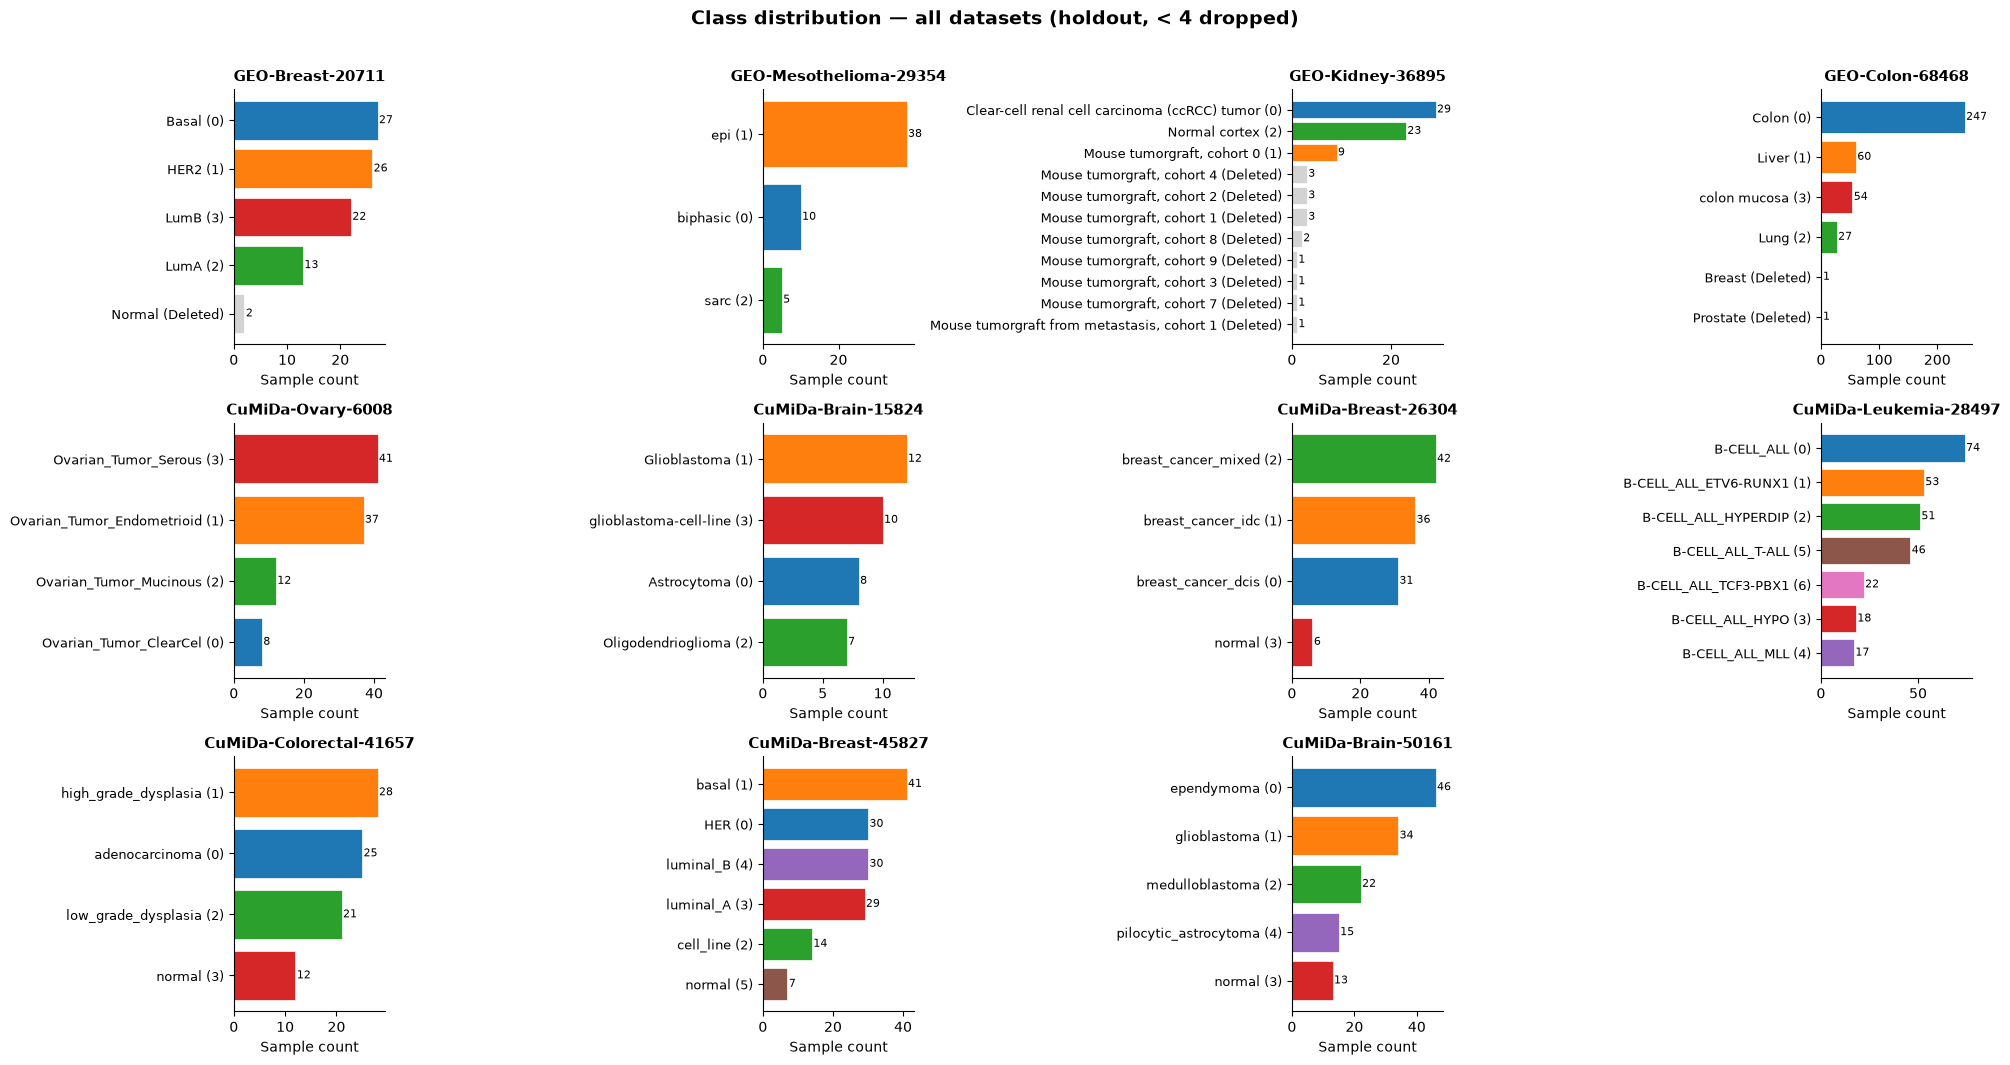

In [5]:
display(Image(filename=str(SPLIT_ROOT / f'k{INSPECT_K}' / 'visualizations' / 'all_datasets_class_distribution.png')))
display(Image(filename=str(SPLIT_ROOT / f'k{INSPECT_K}' / 'visualizations' / 'all_datasets_metric_comparison.png')))


## Inspect the Held-Out Test Set

Exported once per dataset (raw feature space) — `test_set.csv` for bulk use, `manifest.csv` to
list samples, and one JSON per sample under `samples/` for later single-sample UI testing.

In [6]:
manifest = pd.read_csv(ds_root / 'test_set' / 'manifest.csv')
manifest

,sample_id,true_label,row_index
0,GSM519730,LumB,0
1,GSM519732,LumB,1
2,GSM519735,LumB,2
3,GSM519743,LumB,3
4,GSM519746,Basal,4
5,GSM519758,HER2,5
6,GSM519759,Basal,6
7,GSM519762,LumA,7
8,GSM519767,HER2,8
9,GSM519768,Basal,9


In [7]:
# One sample, as the UI would load it for a single-sample prediction demo.
sample_id = manifest.iloc[0]['sample_id']
sample_payload = json.loads((ds_root / 'test_set' / 'samples' / f'{sample_id}.json').read_text())
print('sample_id:', sample_payload['sample_id'], '· true_label:', sample_payload['true_label'])
list(sample_payload['features'].items())[:10]

sample_id: GSM519730 · true_label: LumB


[('1007_s_at', 10.155350685119629),
 ('1053_at', 7.814582824707031),
 ('117_at', 6.110536098480225),
 ('121_at', 6.691348552703857),
 ('1255_g_at', 2.503929853439331),
 ('1294_at', 7.623169422149658),
 ('1316_at', 5.015544891357422),
 ('1320_at', 3.8151817321777344),
 ('1405_i_at', 8.775683403015137),
 ('1431_at', 3.5864837169647217)]

## Inspect Outputs — Random Forest

`cv_results.csv` (one row per repeated-training run), `cv_summary.csv` (mean ± std across runs),
and the rules mined from the winning run.

In [8]:
FS_METHOD = 'mrmr_k50'
rf_dir = ds_root / FS_METHOD / 'rf'

cv_results = pd.read_csv(rf_dir / 'models' / 'cv_results.csv')
cv_summary = pd.read_csv(rf_dir / 'models' / 'cv_summary.csv')
print('Per-run metrics (n_repeats rows):'); display(cv_results)
print('Mean ± std across runs:'); display(cv_summary)

Per-run metrics (n_repeats rows):


,run,seed,accuracy,balanced_accuracy,f1,f1_macro,precision,recall,roc_auc,log_loss
0,0,0,0.857143,0.875,0.851786,0.851786,0.854167,0.875,0.92500,0.669640
1,1,1,0.857143,0.875,0.851786,0.851786,0.854167,0.875,0.93750,0.653531
2,2,2,0.857143,0.875,0.851786,0.851786,0.854167,0.875,0.90625,0.731139
3,3,3,0.857143,0.875,0.851786,0.851786,0.854167,0.875,0.95000,0.649296
4,4,4,0.857143,0.875,0.851786,0.851786,0.854167,0.875,0.95000,0.635663
5,5,5,0.857143,0.875,0.851786,0.851786,0.854167,0.875,0.93750,0.675369
6,6,6,0.857143,0.875,0.851786,0.851786,0.854167,0.875,0.92500,0.668256
7,7,7,0.857143,0.875,0.851786,0.851786,0.854167,0.875,0.91250,0.703275
8,8,8,0.857143,0.875,0.851786,0.851786,0.854167,0.875,0.93750,0.652361
9,9,9,0.857143,0.875,0.851786,0.851786,0.854167,0.875,0.93125,0.663825


Mean ± std across runs:


,metric,mean,std
0,accuracy,0.857143,0.000000
1,balanced_accuracy,0.875000,0.000000
2,f1,0.851786,0.000000
3,f1_macro,0.851786,0.000000
4,precision,0.854167,0.000000
5,recall,0.875000,0.000000
6,roc_auc,0.931250,0.014434
7,log_loss,0.670236,0.028097


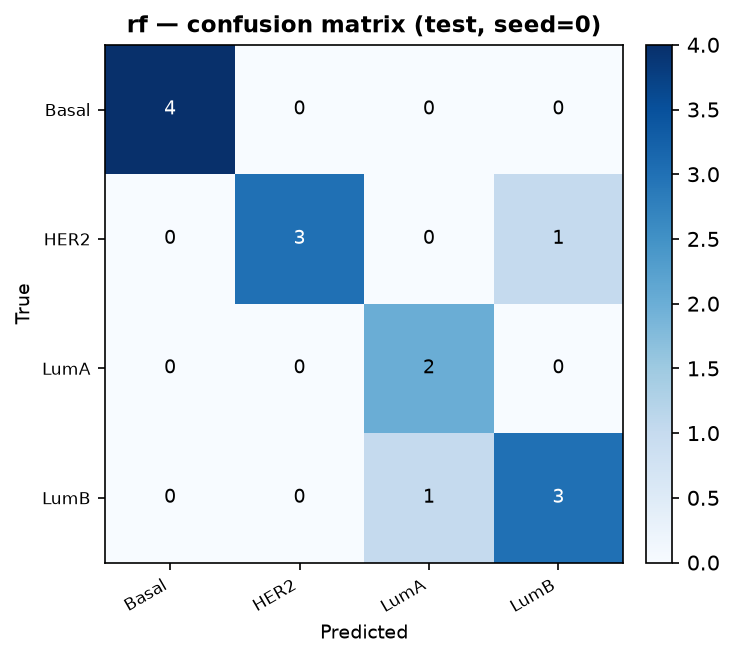

,pred_Basal,pred_HER2,pred_LumA,pred_LumB
true_Basal,4,0,0,0
true_HER2,0,3,0,1
true_LumA,0,0,2,0
true_LumB,0,0,1,3


In [9]:
# Confusion matrix of the winning run, on the held-out test set.
display(Image(filename=str(rf_dir / 'models' / 'confusion_matrix_test.png')))
pd.read_csv(rf_dir / 'models' / 'confusion_matrix_test.csv', index_col=0)

In [10]:
rf_rules = pd.read_csv(rf_dir / 'rules' / 'rules.csv')
rf_summary = json.loads((rf_dir / 'rules' / 'rules_summary.json').read_text())
print('RF set-level (train) + best-run train+test metrics:')
print('  test :', rf_summary.get('best_run_test_metrics'))
print('  train:', rf_summary.get('best_run_train_metrics'))
rf_rules.head(10)


RF set-level (train) + best-run test metrics:
{
  "model": "rf",
  "n_rules": 80,
  "coverage": 1.0,
  "mean_fidelity": 0.9478,
  "per_class": {
    "Basal": 20,
    "HER2": 20,
    "LumA": 20,
    "LumB": 20
  },
  "n_rules_raw": 1852,
  "n_rules_passed_filter": 884,
  "n_rules_kept": 80,
  "n_dropped_by_filter": 968,
  "n_dropped_by_cap": 804,
  "best_seed": 0,
  "best_run_test_metrics": {
    "accuracy": 0.8571428571428571,
    "balanced_accuracy": 0.875,
    "f1": 0.8517857142857144,
    "f1_macro": 0.8517857142857144,
    "precision": 0.8541666666666666,
    "recall": 0.875,
    "roc_auc": 0.925,
    "log_loss": 0.6696401320380797
  }
}


,antecedents,consequents,support,confidence,error,lift,class_specificity,fidelity,strength_score,n_conditions
0,"ERBB2<=5.481, GTSE1<=5.511, CYP4X1>7.389",Class=LumA,0.1486,1.0000,0.0000,6.7273,1.0000,1.0000,1.000000,3
1,"GTSE1<=5.405, CYP4X1>7.389",Class=LumA,0.1486,1.0000,0.0000,6.7273,1.0000,1.0000,1.000000,2
2,"PTGER3>3.099, MKI67<=6.111",Class=LumA,0.1622,0.9167,0.0833,6.1667,0.8333,0.9167,0.916667,2
3,"ERBB2<=3.913, CYP4X1>7.671, BIRC5<=6.655",Class=LumA,0.1351,1.0000,0.0000,6.7273,1.0000,1.0000,0.909091,3
4,"CDK12<=4.47, GTSE1<=5.405, CYP4X1>7.556",Class=LumA,0.1351,1.0000,0.0000,6.7273,1.0000,1.0000,0.909091,3
5,ERBB2>10.78,Class=HER2,0.2568,1.0000,0.0000,3.3636,1.0000,1.0000,0.863636,1
6,ERBB2>5.52,Class=HER2,0.2568,1.0000,0.0000,3.3636,1.0000,1.0000,0.863636,1
7,"CCNB2>6.348, ERBB2>5.52",Class=HER2,0.2568,1.0000,0.0000,3.3636,1.0000,1.0000,0.863636,2
8,"PRR11>7.276, ERBB2>4.28",Class=HER2,0.2568,1.0000,0.0000,3.3636,1.0000,1.0000,0.863636,2
9,ERBB2>4.344,Class=HER2,0.2568,1.0000,0.0000,3.3636,1.0000,1.0000,0.863636,1


In [11]:
# Generalisation check: the SAME (train-mined) rules re-evaluated on the held-out test set.
rf_test_eval = pd.read_csv(rf_dir / 'rules' / 'rules_test_eval.csv')
rf_test_eval.head(10)

,antecedents,consequents,n_conditions,support_test,confidence_test,error_test,lift_test,class_specificity_test,fidelity_test,strength_score_test
0,"ERBB2<=5.481, GTSE1<=5.511, CYP4X1>7.389",Class=LumA,3,0.2143,0.6667,0.3333,4.6667,0.3333,0.6667,0.666667
1,"GTSE1<=5.405, CYP4X1>7.389",Class=LumA,2,0.2857,0.5000,0.5000,3.5000,0.0000,0.5000,0.500000
2,"PTGER3>3.099, MKI67<=6.111",Class=LumA,2,0.0714,1.0000,0.0000,7.0000,1.0000,1.0000,0.500000
3,"ERBB2<=3.913, CYP4X1>7.671, BIRC5<=6.655",Class=LumA,3,0.0714,1.0000,0.0000,7.0000,1.0000,1.0000,0.500000
4,"CDK12<=4.47, GTSE1<=5.405, CYP4X1>7.556",Class=LumA,3,0.2143,0.3333,0.6667,2.3333,-0.3333,0.3333,0.166667
5,ERBB2>10.78,Class=HER2,1,0.2143,1.0000,0.0000,3.5000,1.0000,1.0000,0.750000
6,ERBB2>5.52,Class=HER2,1,0.2143,1.0000,0.0000,3.5000,1.0000,1.0000,0.750000
7,"CCNB2>6.348, ERBB2>5.52",Class=HER2,2,0.2143,1.0000,0.0000,3.5000,1.0000,1.0000,0.750000
8,"PRR11>7.276, ERBB2>4.28",Class=HER2,2,0.2143,1.0000,0.0000,3.5000,1.0000,1.0000,0.750000
9,ERBB2>4.344,Class=HER2,1,0.2143,1.0000,0.0000,3.5000,1.0000,1.0000,0.750000


## Inspect Outputs — Decision Tree

In [14]:
dt_dir = ds_root / FS_METHOD / 'dt'
print((dt_dir / 'rules' / 'rules_human.txt').read_text())
pd.read_csv(dt_dir / 'rules' / 'rules.csv')

IF PTGER3<=3.099 AND ERBB2<=4.28 AND TTC30B>4.355 AND CASC1>3.194 THEN Class=LumB (conf=1.00, support=0.20, lift=4.11, fidelity=1.00)
IF PTGER3>3.099 AND CYP4X1>7.613 AND NDUFA7>8.675 THEN Class=LumA (conf=1.00, support=0.12, lift=6.73, fidelity=1.00)
IF PTGER3<=3.099 AND ERBB2<=4.28 AND TTC30B<=4.355 AND FBXO10>2.571 AND CCDC124<=3.472 THEN Class=Basal (conf=1.00, support=0.24, lift=3.22, fidelity=1.00)
IF PTGER3<=3.099 AND ERBB2>4.28 AND ZFR>6.214 THEN Class=HER2 (conf=1.00, support=0.23, lift=3.36, fidelity=1.00)


,antecedents,consequents,support,confidence,error,lift,class_specificity,fidelity,strength_score,n_conditions
0,"PTGER3<=3.099, ERBB2<=4.28, TTC30B>4.355, CASC...",Class=LumB,0.2027,1.0,0.0,4.1111,1.0,1.0,0.833333,4
1,"PTGER3>3.099, CYP4X1>7.613, NDUFA7>8.675",Class=LumA,0.1216,1.0,0.0,6.7273,1.0,1.0,0.818182,3
2,"PTGER3<=3.099, ERBB2<=4.28, TTC30B<=4.355, FBX...",Class=Basal,0.2432,1.0,0.0,3.2174,1.0,1.0,0.782609,5
3,"PTGER3<=3.099, ERBB2>4.28, ZFR>6.214",Class=HER2,0.2297,1.0,0.0,3.3636,1.0,1.0,0.772727,3


## Gene Descriptions — Biological Annotation (separate step)

Enrich the genes appearing in the holdout rules with biological info from each dataset's
platform file (`Platform_Annotations/…`): **Gene title, Entrez ID, GenBank, chromosome,
GO Biological Process / Cellular Component / Molecular Function**. Writes
`gene_description.csv` + `gene_description.md` next to each `genes_in_rules.csv` under
`outputs_holdout/{dataset}/{fs_method}/{rf,dt}/rules/`.

This is a **separate step**: it reads existing rule outputs (no re-training), so it can run
any time after `run_rule_extraction_holdout()`.

In [12]:
# Separate step -- annotate holdout rule genes from the platform files.
gene_desc = pipe.describe_genes_in_rules_holdout(dataset_names=None, k=INSPECT_K)
gene_desc


╭─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╮
│ Gene Descriptions (Holdout) — Biological Annotation of Rule Genes                                               │
│ Enrich genes_in_rules with platform annotation (Gene title, GO, …)                                              │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

──────────────────────────────────────────── Dataset: GEO-Breast-20711 ────────────────────────────────────────────

  ✓ Loaded platform annotation: 54,675 probes (nbci) from GPL570.annot.gz

  ✓ Gene descriptions → C:\Users\Bao 
Nguyen\LearningWithClaude\LV_code\outputs_holdout\GEO-Breast-20711\boruta\dt\rules (csv + md, 6 genes)

  ✓ Gene descriptions → C:\Users\Bao 
Nguyen\LearningWithClaude\LV_code\outputs_holdout\GEO-Breast-20711\boruta\rf\rules (csv + md, 58 genes)

...

  ✓ Gene descriptions → C:\Users\Bao 
Nguyen\LearningWithClaude\LV_code\outputs_holdout\CuMiDa-Brain-50161\boruta\dt\rules (csv + md, 5 genes)

  ✓ Gene descriptions → C:\Users\Bao 
Nguyen\LearningWithClaude\LV_code\outputs_holdout\CuMiDa-Brain-50161\boruta\rf\rules (csv + md, 185 genes)

  ✓ Gene descriptions → C:\Users\Bao 
Nguyen\LearningWithClaude\LV_code\outputs_holdout\CuMiDa-Brain-50161\mrmr_miq\dt\rules (csv + md, 7 genes)

  ✓ Gene descriptions → C:\Users\Bao 
Nguyen\LearningWithClaude\LV_code\outputs_holdout\CuMiDa-Brain-50161\mrmr_miq\rf\rules (csv + md, 42 genes)

{'GEO-Breast-20711': {'boruta/dt': {'n_genes': 6,
   'n_annotated': 6,
   'paths': {'csv': 'C:\\Users\\Bao Nguyen\\LearningWithClaude\\LV_code\\outputs_holdout\\GEO-Breast-20711\\boruta\\dt\\rules\\gene_description.csv',
    'md': 'C:\\Users\\Bao Nguyen\\LearningWithClaude\\LV_code\\outputs_holdout\\GEO-Breast-20711\\boruta\\dt\\rules\\gene_description.md'}},
  'boruta/rf': {'n_genes': 58,
   'n_annotated': 58,
   'paths': {'csv': 'C:\\Users\\Bao Nguyen\\LearningWithClaude\\LV_code\\outputs_holdout\\GEO-Breast-20711\\boruta\\rf\\rules\\gene_description.csv',
    'md': 'C:\\Users\\Bao Nguyen\\LearningWithClaude\\LV_code\\outputs_holdout\\GEO-Breast-20711\\boruta\\rf\\rules\\gene_description.md'}},
  'mrmr_miq/dt': {'n_genes': 9,
   'n_annotated': 9,
   'paths': {'csv': 'C:\\Users\\Bao Nguyen\\LearningWithClaude\\LV_code\\outputs_holdout\\GEO-Breast-20711\\mrmr_miq\\dt\\rules\\gene_description.csv',
    'md': 'C:\\Users\\Bao Nguyen\\LearningWithClaude\\LV_code\\outputs_holdout\\GEO-Breas

In [13]:
# Preview one dataset's gene descriptions (RF, mrmr_miq)
gene_desc_csv = rf_dir / 'rules' / 'gene_description.csv'
if gene_desc_csv.exists():
    display(pd.read_csv(gene_desc_csv).head(10))
else:
    print(f'Not found: {gene_desc_csv}')

,gene,gene_title,entrez_id,genbank_acc,refseq,unigene_symbol,unigene_id,gi,nucleotide_title,target_description,...,species,chromosome,chromosome_annotation,go_biological_process,go_cellular_component,go_molecular_function,n_rules,classes,probes,annotated
0,ERBB2,erb-b2 receptor tyrosine kinase 2,2064.0,AF177761,NaN,NaN,NaN,10181232.0,"Homo sapiens herstatin (HER-2) mRNA, alternati...",NaN,...,NaN,17q12,"Chromosome 17, NC_000017.11 (39688084..39728662)",ERBB2 signaling pathway; MAPK cascade; cell pr...,apical plasma membrane; basolateral plasma mem...,ATP binding; ErbB-3 class receptor binding; RN...,56,Basal;HER2;LumA;LumB,210930_s_at; 216836_s_at; 234354_x_at,True
1,CDK12,cyclin dependent kinase 12,51755.0,AW305119,NaN,NaN,NaN,6717322.0,xv99g09.x1 NCI_CGAP_Brn53 Homo sapiens cDNA cl...,NaN,...,NaN,17q12,"Chromosome 17, NC_000017.11 (39461486..39567560)",RNA splicing; mRNA processing; phosphorylation...,cyclin K-CDK12 complex; nuclear cyclin-depende...,ATP binding; RNA polymerase II carboxy-termina...,21,Basal;LumA;LumB,1556654_at; 1556655_s_at; 213557_at; 219226_at...,True
2,TTC30B,tetratricopeptide repeat domain 30B,150737.0,AW117691,NaN,NaN,NaN,6086275.0,xe34d08.x1 NCI_CGAP_Ut1 Homo sapiens cDNA clon...,NaN,...,NaN,2q31.2,"Chromosome 2, NC_000002.12 (177550152..1775527...",cilium assembly; intraciliary transport,ciliary tip; cilium; intraciliary transport pa...,protein binding,16,Basal;LumB,243413_at,True
3,PTGER3,prostaglandin E receptor 3,5733.0,X83858,NaN,NaN,NaN,633209.0,H.sapiens mRNA for prostaglandin E receptor (E...,NaN,...,NaN,1p31.2,"Chromosome 1, NC_000001.11 (70852353..71047814...",G-protein coupled receptor signaling pathway; ...,brush border membrane; cell surface; integral ...,prostaglandin E receptor activity,14,Basal;LumA;LumB,210375_at; 210831_s_at; 210833_at,True
4,BIRC5,baculoviral IAP repeat containing 5,332.0,NM_001168,NaN,NaN,NaN,59859877.0,Homo sapiens baculoviral IAP repeat containing...,NaN,...,NaN,17q25,"Chromosome 17, NC_000017.11 (78214196..78225635)",apoptotic process; cell division; inhibition o...,"chromosome passenger complex; chromosome, cent...",Ran GTPase binding; chaperone binding; cystein...,13,Basal;HER2;LumA;LumB,202095_s_at,True
5,KNL1,kinetochore scaffold 1,57082.0,BF248364,NaN,NaN,NaN,11164799.0,601821412F1 NIH_MGC_62 Homo sapiens cDNA clone...,NaN,...,NaN,15q14,"Chromosome 15, NC_000015.10 (40594012..40664342)",CENP-A containing nucleosome assembly; acrosom...,acrosomal vesicle; condensed chromosome kineto...,protein binding,12,Basal;HER2;LumA;LumB,228323_at,True
6,CYP4X1,cytochrome P450 family 4 subfamily X member 1,260293.0,AA557324,NaN,NaN,NaN,2327801.0,nl81a02.s1 NCI_CGAP_Br2 Homo sapiens cDNA clon...,NaN,...,NaN,1,"Chromosome 1, NC_000001.11 (46961364..47055432)",oxidation-reduction process,endoplasmic reticulum membrane; integral compo...,aromatase activity; heme binding; iron ion bin...,11,Basal;LumA;LumB,227702_at,True
7,CCDC124,coiled-coil domain containing 124,115098.0,BE733510,NaN,NaN,NaN,10147502.0,601566040F1 NIH_MGC_21 Homo sapiens cDNA clone...,NaN,...,NaN,19p13.11,"Chromosome 19, NC_000019.10 (17933015..17943985)",cell cycle; cell division,cytoplasm; microtubule organizing center; midb...,poly(A) RNA binding,9,Basal;LumB,225453_x_at,True
8,CCNB2,cyclin B2,9133.0,NM_004701,NaN,NaN,NaN,332205979.0,"Homo sapiens cyclin B2 (CCNB2), mRNA",NaN,...,NaN,15q22.2,"Chromosome 15, NC_000015.10 (59105085..59125045)",G2/M transition of mitotic cell cycle; T cell ...,cell-cell adherens junction; centrosome; cytos...,cadherin binding involved in cell-cell adhesio...,9,Basal;HER2;LumA;LumB,202705_at,True
9,EPB41L4B,erythrocyte membrane protein band 4.1 like 4B,54566.0,NM_019114,NaN,NaN,NaN,565324187.0,Homo sapiens erythrocyte membrane protein band...,NaN,...,NaN,9q31-q32,"Chromosome 9, NC_000009.12 (109171974..1093209...",actomyosin structure organization; positive re...,apical part of cell; bicellular tight junction...,cytoskeletal protein binding; structural const...,9,Basal;LumB

## Cross-Check (rf vs. decisiontree) & Provenance

`DATASET_PROVENANCE_HOLDOUT.md` compares every fs_method × model on `select_metric` (default
`f1_macro`).

In [15]:
crosscheck = json.loads((ds_root / FS_METHOD / 'compare' / 'crosscheck.json').read_text())
print(json.dumps(crosscheck, indent=2))

{
  "fs_method": "mrmr_miq",
  "model_a": "rf",
  "model_b": "decisiontree",
  "n_a": 80,
  "n_b": 4,
  "n_overlap": 0,
  "jaccard": 0.0,
  "overlap": [],
  "literal_overlap": 12,
  "literal_jaccard": 0.1319,
  "shared_literals": [
    {
      "gene": "CASC1",
      "direction": "High",
      "consequent": "Class=LumB"
    },
    {
      "gene": "CCDC124",
      "direction": "Low",
      "consequent": "Class=Basal"
    },
    {
      "gene": "CYP4X1",
      "direction": "High",
      "consequent": "Class=LumA"
    },
    {
      "gene": "ERBB2",
      "direction": "High",
      "consequent": "Class=HER2"
    },
    {
      "gene": "ERBB2",
      "direction": "Low",
      "consequent": "Class=Basal"
    },
    {
      "gene": "ERBB2",
      "direction": "Low",
      "consequent": "Class=LumB"
    },
    {
      "gene": "FBXO10",
      "direction": "High",
      "consequent": "Class=Basal"
    },
    {
      "gene": "PTGER3",
      "direction": "High",
      "consequent": "Class=LumA"
  

In [16]:
print((ds_root / 'DATASET_PROVENANCE_HOLDOUT.md').read_text())



---

## --- DATASET CLASS DISTRIBUTION LOG ---

> Auto-generated by `update_dataset_description()` on 2026-07-26 17:43:19  
> Source dataset: `Breast_GSE20711_probe.csv`

> **NOTE â€” rare-class removal was applied before training.**  
> 2 sample(s) across 1 class(es) were dropped (threshold: < 4 samples/class): `Normal` (n=2).  
> Training set: 90 â†’ **88** samples. All models were trained on this reduced set.

> **Train / test split:** 74 train / 14 test (16% test)

| Class Name | Train Count | Test Count |
|:-----------|:-----------:|:-----------:|
| Basal | 23 | 4 |
| HER2 | 22 | 4 |
| LumA | 11 | 2 |
| LumB | 18 | 4 |

**Total features retained:** 54623  
**Rare-sample filter threshold:** < 4 samples per class  

| Class Name | Original Sample Count | Encoded Integer ID | Operational Status |
|:-----------|:---------------------:|:------------------:|:-------------------|
| Basal | 27 | 0 | KEPT |
| HER2 | 26 | 1 | KEPT |
| LumA | 13 | 2 | KEPT |
| LumB | 22 | 3 | KEPT |
| Norm